<a href="https://colab.research.google.com/github/ChariteshReddyPatlolla/stock-price-predector/blob/main/final_practical_stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1-3121476909.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2023-01-01', end='2025-06-03', interval='1d')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-1-3121476909.py:88: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actual = yf.download(ticker, start=last_date + pd.Timedelta(days=1), end=datetime.datetime.today(), interval='1d')
[*********************100%***********************]  1 of 1 completed


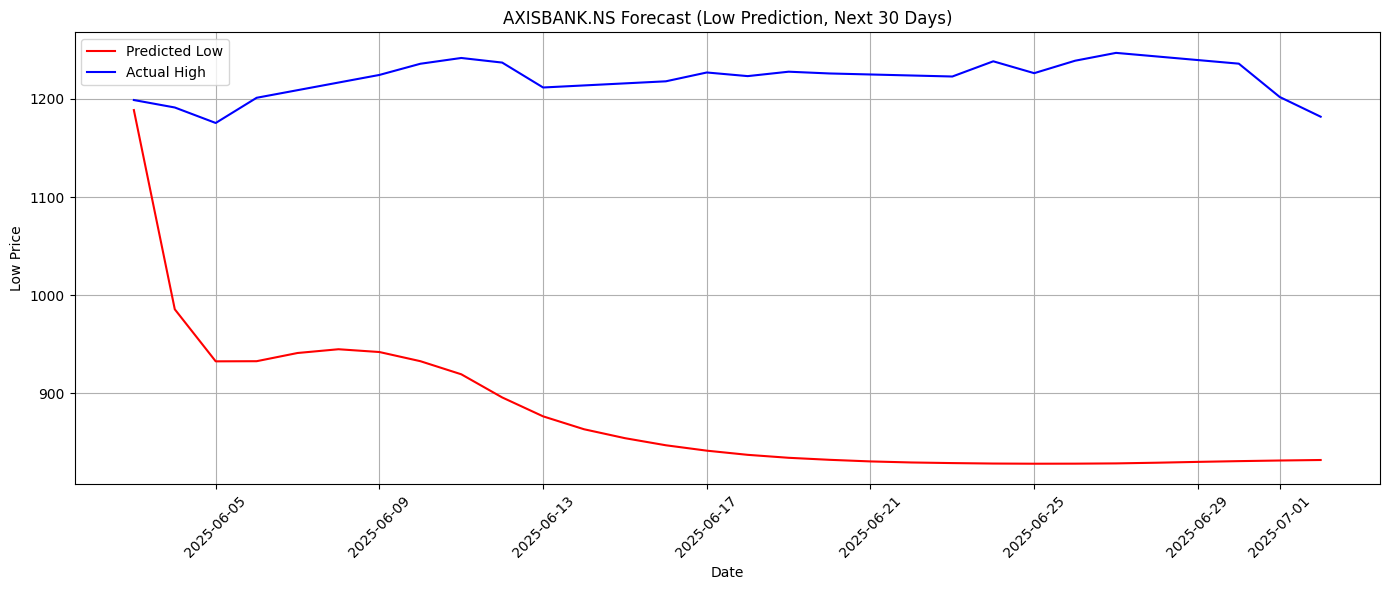

In [ ]:
# Required Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
import datetime

# --------------------------
# Global Config
# --------------------------
ticker = 'AXISBANK.NS'
target_col = 'Low'
future_days = 30
window_size = 60
output_size = 7
epochs = 150

# --------------------------
# Step 1: Download and Preprocess Data
# --------------------------
def load_and_preprocess_data(ticker, target_col):
    df = yf.download(ticker, start='2023-01-01', end='2025-06-03', interval='1d')
    df = df[['Open', 'High', 'Low', 'Close']].dropna()
    df = df.ewm(span=5).mean()
    return df

# --------------------------
# Step 2: Scale Data
# --------------------------
def scale_data(df):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)
    return scaled_data, scaler

# --------------------------
# Step 3: Create Sequences
# --------------------------
def create_sequences(data, window_size, output_size, col_index):
    X, y = [], []
    for i in range(len(data) - window_size - output_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + output_size, col_index])
    return np.array(X), np.array(y).reshape(-1, output_size, 1)

# --------------------------
# Step 4: Build Model
# --------------------------
def build_lstm_model(input_shape, output_size):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape))
    model.add(RepeatVector(output_size))
    model.add(LSTM(64, return_sequences=True))
    model.add(TimeDistributed(Dense(32, activation='relu')))
    model.add(TimeDistributed(Dense(1)))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# --------------------------
# Step 5: Predict Future Data
# --------------------------
def predict_future(model, input_seq, scaler, col_index, steps):
    predicted = []
    for _ in range(steps):
        pred = model.predict(input_seq, verbose=0)  # shape: (1, 7, 1)
        next_day = pred[:, 0, :]  # take first day

        full_fake_row = np.zeros((1, input_seq.shape[2]))
        full_fake_row[0, col_index] = next_day[0, 0]
        inv_scaled = scaler.inverse_transform(full_fake_row)
        predicted.append(inv_scaled[0, col_index])

        next_row_scaled = np.zeros((1, 1, input_seq.shape[2]))
        next_row_scaled[0, 0, col_index] = next_day
        input_seq = np.concatenate([input_seq[:, 1:, :], next_row_scaled], axis=1)

    return predicted

# --------------------------
# Step 6: Plot Results
# --------------------------
def plot_results(predicted, df, ticker, target_col, future_days):
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
    actual = yf.download(ticker, start=last_date + pd.Timedelta(days=1), end=datetime.datetime.today(), interval='1d')

    plt.figure(figsize=(14, 6))
    plt.plot(future_dates[:len(predicted)], predicted, label=f'Predicted {target_col}', color='red')
    if not actual.empty and 'High' in actual.columns:
        plt.plot(actual.index, actual['Low'], label='Actual Low', color='blue')

    plt.title(f'{ticker} Forecast ({target_col} Prediction, Next {future_days} Days)')
    plt.xlabel('Date')
    plt.ylabel(f'{target_col} Price')
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# Main Workflow
# --------------------------
df = load_and_preprocess_data(ticker, target_col)
scaled_data, scaler = scale_data(df)
col_index = df.columns.get_loc(target_col)
X, y = create_sequences(scaled_data, window_size, output_size, col_index)
X = X.reshape((X.shape[0], window_size, 4))  # 4 features: OHLC

model = build_lstm_model((window_size, 4), output_size)
model.fit(X, y, epochs=epochs, batch_size=32, verbose=0)

input_seq = X[-1:]
predicted = predict_future(model, input_seq, scaler, col_index, future_days)
plot_results(predicted, df, ticker, target_col, future_days)


/tmp/ipython-input-1-3121476909.py:88: FutureWarning: YF.download() has changed argument auto_adjust default to True
  actual = yf.download(ticker, start=last_date + pd.Timedelta(days=1), end=datetime.datetime.today(), interval='1d')
[*********************100%***********************]  1 of 1 completed


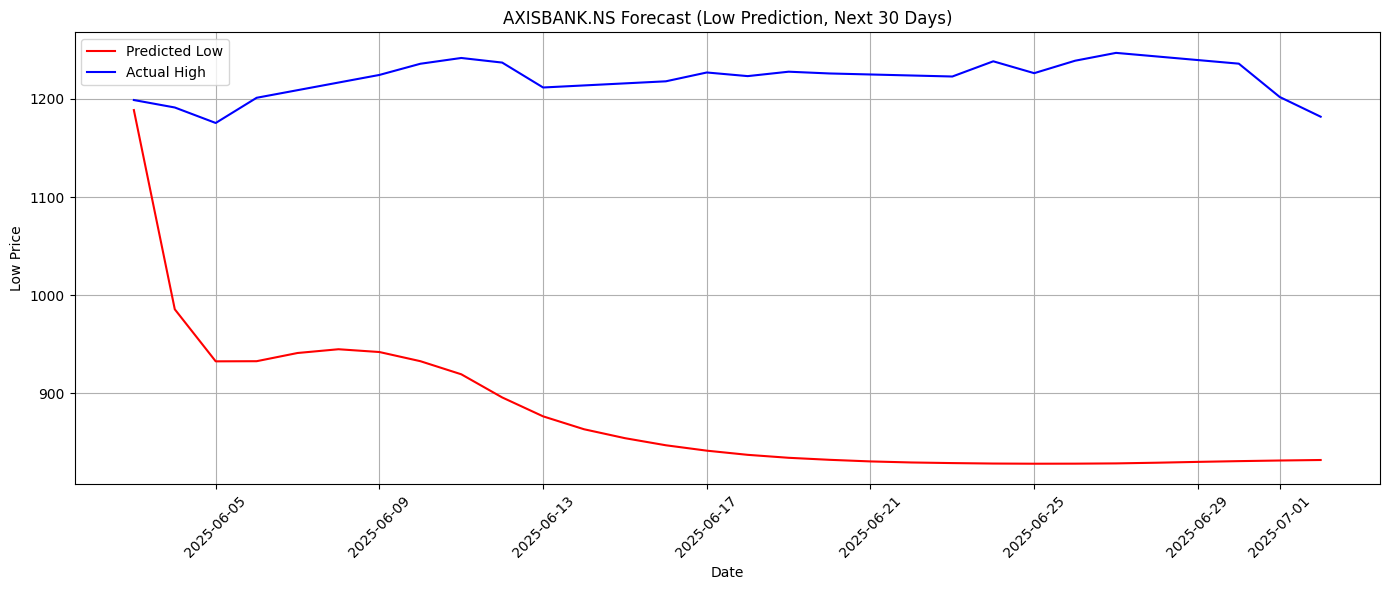

In [ ]:
plot_results(predicted, df, ticker, target_col, future_days)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


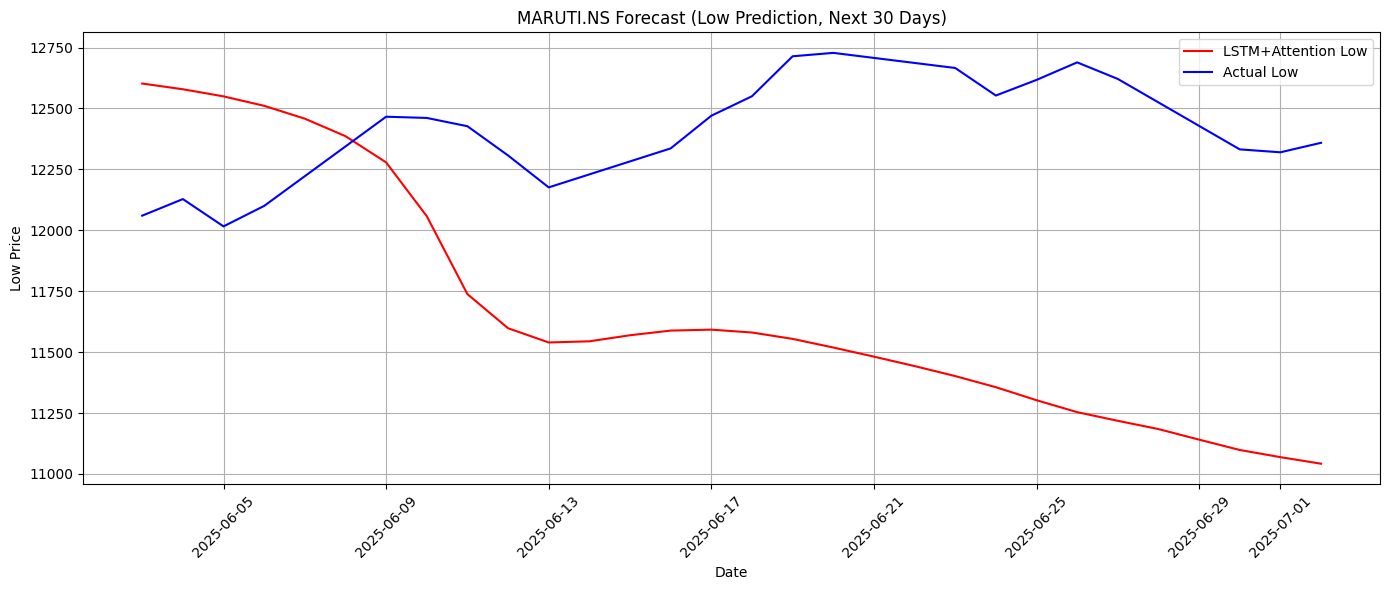

In [ ]:
# Required Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Attention

# --------------------------
# Global Config
# --------------------------
ticker = 'MARUTI.NS'
target_col = 'Low'
future_days = 30
window_size = 60
output_size = 7
epochs = 200

# --------------------------
# Step 1: Download and Preprocess Data
# --------------------------
def load_and_preprocess_data(ticker, target_col):
    # Addressing FutureWarning: YF.download() has changed argument auto_adjust default to True
    df = yf.download(ticker, start='2024-06-03', end='2025-06-03', interval='1d', auto_adjust=True)
    df = df[['Open', 'High', 'Low', 'Close']].dropna()
    df = df.ewm(span=5).mean()
    return df

# --------------------------
# Step 2: Scale Data
# --------------------------
def scale_data(df):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)
    return scaled_data, scaler

# --------------------------
# Step 3: Create Sequences
# --------------------------
def create_sequences(data, window_size, output_size, col_index):
    X, y = [], []
    for i in range(len(data) - window_size - output_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + output_size, col_index])
    return np.array(X), np.array(y).reshape(-1, output_size, 1)

# --------------------------
# Step 4: Build Hybrid Model (LSTM + Attention)
# --------------------------
def build_lstm_attention_model(input_shape, output_size):
    inputs = Input(shape=input_shape)
    # Addressing UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer.
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    attention = Attention()([lstm_out, lstm_out])
    context = LSTM(64)(attention)
    repeat = RepeatVector(output_size)(context)
    decoder = LSTM(64, return_sequences=True)(repeat)
    dense = TimeDistributed(Dense(32, activation='relu'))(decoder)
    outputs = TimeDistributed(Dense(1))(dense)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# --------------------------
# Step 5: Predict Future Data (LSTM + Attention)
# --------------------------
def predict_future(model, input_seq, scaler, col_index, steps):
    predicted = []
    for _ in range(steps):
        pred = model.predict(input_seq, verbose=0)
        next_day = pred[:, 0, :]

        # Create dummy full row for inverse transform
        full_fake_row = np.zeros((1, input_seq.shape[2]))
        full_fake_row[0, col_index] = next_day[0, 0]
        inv_scaled = scaler.inverse_transform(full_fake_row)
        predicted.append(inv_scaled[0, col_index])

        # Update input sequence with predicted value
        next_row_scaled = np.zeros((1, 1, input_seq.shape[2]))
        # Addressing DeprecationWarning: Conversion of an array with ndim > 0 to a scalar
        next_row_scaled[0, 0, col_index] = next_day[0, 0]
        input_seq = np.concatenate([input_seq[:, 1:, :], next_row_scaled], axis=1)

    return predicted

# --------------------------
# Step 6: Plot Results
# --------------------------
def plot_results(predicted, df, ticker, target_col, future_days):
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
    # Addressing FutureWarning: YF.download() has changed argument auto_adjust default to True
    actual = yf.download(ticker, start=last_date + pd.Timedelta(days=1), end=datetime.datetime.today(), interval='1d', auto_adjust=True)


    plt.figure(figsize=(14, 6))
    plt.plot(future_dates[:len(predicted)], predicted, label=f'LSTM+Attention {target_col}', color='red')
    if not actual.empty and target_col in actual.columns:
        plt.plot(actual.index, actual[target_col], label=f'Actual {target_col}', color='blue')

    plt.title(f'{ticker} Forecast ({target_col} Prediction, Next {future_days} Days)')
    plt.xlabel('Date')
    plt.ylabel(f'{target_col} Price')
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --------------------------
# Main Workflow
# --------------------------
df = load_and_preprocess_data(ticker, target_col)
scaled_data, scaler = scale_data(df)
col_index = df.columns.get_loc((target_col, ticker))
X, y = create_sequences(scaled_data, window_size, output_size, col_index)
X = X.reshape((X.shape[0], window_size, 4))

model = build_lstm_attention_model((window_size, 4), output_size)
model.fit(X, y, epochs=epochs, batch_size=32, verbose=0)

input_seq = X[-1:]
predicted = predict_future(model, input_seq, scaler, col_index, future_days)

plot_results(predicted, df, ticker, target_col, future_days)

In [ ]:
print(target_col)           # should print something like "Close"
print(df.columns.tolist())

Low
[('Open', 'AXISBANK.NS'), ('High', 'AXISBANK.NS'), ('Low', 'AXISBANK.NS'), ('Close', 'AXISBANK.NS')]


In [ ]:
original_series = df[target_col].tolist()

AttributeError: 'DataFrame' object has no attribute 'tolist'